# Homework 1: So sánh thời gian thực thi chương trình nhân ma trận với C, Python, Numpy.

- Họ và tên: Nguyễn Phúc Khang
- MSSV: 22127180

## 1. Khai báo Thư viện

In [14]:
# Cấc thư viện cần thiết
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
# Kích thước ma trận vuông sizes_i x sizes_i
sizes = [10, 25, 50, 75, 100, 250, 500, 750, 1000, 1250]

## 2. Thực hiện chương trình nhân ma trận

### 2.1 Chương trình C

#### Giới thiệu C
C là một ngôn ngữ biên dịch nên có tốc độ thực thi nhanh. Tuy nhiên, khi tăng kích thước của ma trận, thời gian thực thi cũng tăng lên đáng kể do độ phức tạp của thuật toán nhân ma trận là $O(N^3)$.

#### Thực hiện
- Hàm `multiply_matrix` thực hiện phép nhân ma trận bằng ba vòng lặp `for` theo công thức `matrix_c[i][j] += matrix_a[i][k] * matrix_b[k][j]`. 
- Biên dịch mã C và tạo ra một file thực thi tên là `run_time_c`.
- Chạy file thực thi trên và xuất thời gian thực thi cho mỗi phép nhân ma trận vào file `c_times.txt`.
- Trích xuất thời gian thực thi và lưu vào mảng `c_times`.

#### Ưu điểm
- Tốc độ thực thi nhanh, hiệu suất tốt.
- Thời gian thực thi nhanh hơn Python thuần và chậm hơn NumPy.

#### Nhược điểm
- Tuy có tốc độ thực thi nhanh nhưng nếu thuật toán có độ phức tạp lớn thì thời gian thực thi cũng tăng đáng kể.

In [3]:
!gcc 22127180.c -o run_time_c
!./run_time_c > c_times.txt

In [11]:
c_times = []

# Đọc file c_times.txt để lấy kết quả
with open('c_times.txt', 'r') as file:
    lines = file.readlines()
    for line in lines:
        time = float(line.split()[-2])
        c_times.append(time)

# Tạo DataFrame và in kết quả cho C
df_c = pd.DataFrame({
    'Size': sizes,
    'C_Time': c_times
})

print("Execution Times of C:")
print('-'*21)
print(df_c)

Execution Times of C:
---------------------
   Size    C_Time
0    10  0.000003
1    25  0.000056
2    50  0.000422
3    75  0.001452
4   100  0.003312
5   250  0.048853
6   500  0.393241
7   750  1.421240
8  1000  3.490429
9  1250  7.194873


### 2.2 Python thuần và Python với Numpy

In [5]:
def create_matrix(size, value):
    return [[value for _ in range(size)] for _ in range(size)]

### 2.2a Python thuần

Python là một ngôn ngữ thông dịch, thời gian thực thi thường lâu hơn so với các ngôn ngữ biên dịch như C/C++. Điều này có thể được thấy rõ khi kích thước ma trận tăng, thời gian thực thi của Python thuần tăng lên rất nhiều.

#### Thực hiện: 
- Sử dụng Python thuần để tính tích ma trận theo cùng công thức như C.
- Hàm `multiply_pure_python_optimized`: thực hiện phép nhân giữa hai ma trận a và b. Bạn đã tối ưu hóa việc tính toán bằng cách giữ biến sum_value để tích luỹ tổng, thay vì thực hiện việc cộng dồn trực tiếp trên ma trận kết quả.

#### Ưu điểm
- Cho phép phát triển nhanh chóng và thử nghiệm mã, dù thời gian thực thi không tối ưu.

#### Nhược điểm:
- Thời gian thực thi chậm hơn nhiều so với C và NumPy, đặc biệt với kích thước ma trận và độ phức tạp thuật toán lớn.

In [13]:
# Hàm nhân ma trận Python thuần
def multiply_matrix(matrix_a, matrix_b, size):
    matrix_c = create_matrix(size, 0)
    for i in range(size):
        for j in range(size):
            for k in range(size):
                matrix_c[i][j] += matrix_a[i][k] * matrix_b[k][j]
    return matrix_c

# Thực thi do thời gian
python_times = []
for size in sizes:
    # Tạo ma trận A, B và C với giá trị cho trước
    matrix_a = create_matrix(size, 1)
    matrix_b = create_matrix(size, 2)

    # Đo thời gian thực thi cho Python
    start_python = time.time()
    matrix_c = multiply_matrix(matrix_a, matrix_b, size)
    end_python = time.time()
    python_times.append(end_python - start_python)

# Tạo DataFrame cho kết quả
df_python = pd.DataFrame({
    'Size': sizes,
    'Python_Times': python_times, 
})

print("Execution Times of Pure Python:")
print('-' * 36)
print(df_python)

Execution Times of Pure Python:
------------------------------------
   Size  Python_Times
0    10      0.000053
1    25      0.000707
2    50      0.005747
3    75      0.018227
4   100      0.041501
5   250      0.745192
6   500      7.307403
7   750     32.085278
8  1000     76.709131
9  1250    145.204586


### 2.2b Python với Numpy

Numpy là một thư viện tối ưu cho việc tính toán khoa học trong Python. Các phép toán ma trận trong Numpy thường được tối ưu hóa và thực thi nhanh hơn nhiều so với Python thuần. Điều này rõ ràng qua dữ liệu, thậm chí với kích thước ma trận là $1000 \times 1000$, Numpy chỉ mất chưa đầy 1 giây để nhân hai ma trận.

#### Thực hiện 
- Sử dụng hàm `matmul` hoặc toán tử `@` trong thư viện NumPy để thực hiện phép nhân 2 ma trận.

#### Ưu điểm
- Thời gian thực thi rất nhanh do NumPy tận dụng các phép toán vector hóa (vectorization) và tối ưu hóa cấp thấp, giúp thực thi nhanh hơn Python thuần và thậm chí cả C với các phép tính ma trận lớn.
- Dễ sử dụng với các phép toán ma trận.

#### Nhược điểm
- Cần cài đặt thêm thư viện NumPy, không có sẵn trong Python mặc định.
- Hiệu suất cao nhờ vectorization, nhưng sẽ phụ thuộc vào khả năng hỗ trợ vector của CPU.

In [17]:
numpy_times = []

for size in sizes:
    # Tạo ma trận A, B và C với giá trị cho trước
    matrix_a = np.full((size, size), 1)
    matrix_b = np.full((size, size), 2)

    # Đo thời gian thực thi cho Numpy
    start_numpy = time.time()
    matrix_c = matrix_a @ matrix_b
    end_numpy = time.time()
    numpy_times.append(end_numpy - start_numpy)

# Tạo DataFrame cho kết quả
df_numpy = pd.DataFrame({
    'Size': sizes,
    'Numpy_Tiems': numpy_times
})

print("Execution Times of Numpy:")
print('-' * 36)
print(df_numpy)

Execution Times of Numpy:
------------------------------------
   Size  Numpy_Tiems
0    10     0.012369
1    25     0.000271
2    50     0.000276
3    75     0.000269
4   100     0.000584
5   250     0.009587
6   500     0.079521
7   750     0.314360
8  1000     0.880809
9  1250     2.172524


## 3. Trực quan hóa thời gian thực thi chương trình

Execution Times of C, Python and Numpy:
--------------------------------------------------
   Size         C  Pure Python     Numpy
0    10  0.000003     0.000053  0.012369
1    25  0.000056     0.000707  0.000271
2    50  0.000422     0.005747  0.000276
3    75  0.001452     0.018227  0.000269
4   100  0.003312     0.041501  0.000584
5   250  0.048853     0.745192  0.009587
6   500  0.393241     7.307403  0.079521
7   750  1.421240    32.085278  0.314360
8  1000  3.490429    76.709131  0.880809
9  1250  7.194873   145.204586  2.172524


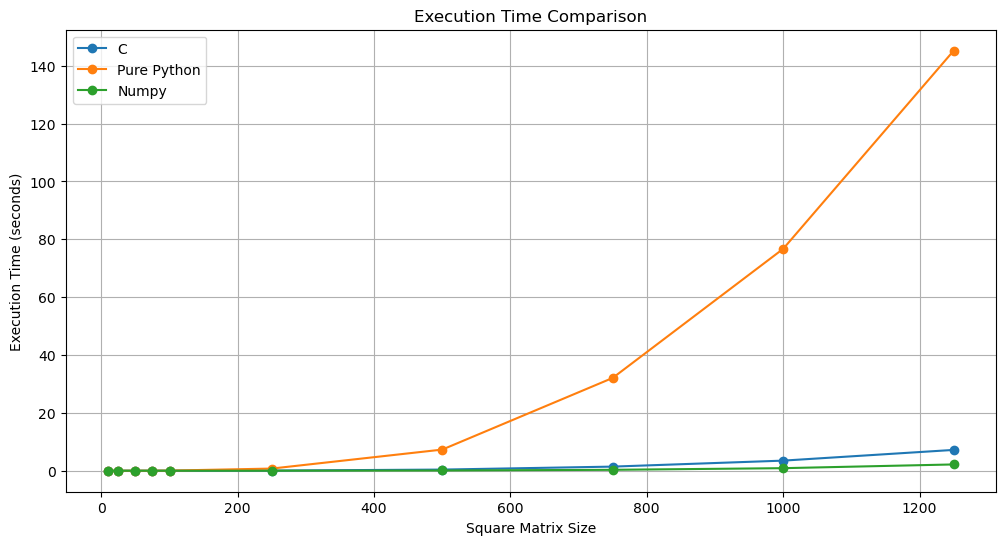

In [21]:
# Tạo DataFrame
df = pd.DataFrame({
    'Size': sizes,
    'C': c_times,
    'Pure Python': python_times,
    'Numpy': numpy_times
})

# In ra bảng dữ liệu
print("Execution Times of C, Python and Numpy:")
print('-'*50)
print(df.to_string(index=True))

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(df['Size'], df['C'], marker='o', label='C')
plt.plot(df['Size'], df['Pure Python'], marker='o', label='Pure Python')
plt.plot(df['Size'], df['Numpy'], marker='o', label='Numpy')
plt.xlabel('Square Matrix Size')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time Comparison')
plt.legend()
plt.grid(True)
plt.show()

## 4. So sánh thời gian thực thi của từng chương trình

- **C**: Thời gian thực thi tăng nhanh khi kích thước đầu vào tăng. Đối với kích thước ma trận nhỏ, C nhanh hơn Python thuần và Numpy. Tuy nhiên, khi kích thước ma trận tăng, thời gian thực thi của C tăng nhanh. Vì vậy, C có thể tối ưu hóa hiệu suất tốt ở mức kích thước ma trận nhỏ nhỏ, nhưng khi xử lý dữ liệu lớn, nó có thể không được tối ưu như các phương pháp khác.

- **Python thuần**: Thời gian thực thi cũng tăng nhanh khi kích thước ma trận tăng. Tại mọi điểm dữ liệu, Python thuần có thời gian chạy chậm hơn cả C và Numpy. Vì Python là một ngôn ngữ thông dịch và thường chậm hơn so với ngôn ngữ biên dịch như C/C++. 

- **Python với Numpy**: Dù thời gian thực thi của Numpy tăng khi kích thước ma trận tăng, nhưng nó vẫn duy trì mức thời gian thực thi thấp nhất trong ba phương pháp, do Numpy được thiết kế để xử lý hiệu quả các phép toán ma trận và số học trên dữ liệu lớn. Kết quả cho thấy rằng Numpy thực sự nhanh hơn nhiều so với C và Python thuần khi xử lý dữ liệu lớn.

## 5. Kết luận

- Nếu yêu cầu hiệu suất cao và không muốn sử dụng thư viện bên ngoài, việc viết chương trình bằng C là một lựa chọn tốt.
- Nếu yêu cầu code dễ đọc, không cần tối ưu hóa tối cao và thử nghiệm nhanh chóng, hãy sử dụng Python thuần.
- Đối với các tác vụ tính toán ma trận và xử lý dữ liệu lớn, nên sử dụng thư viện Numpy để đạt hiệu suất tối ưu nhất.
- Sự khác biệt rõ ràng về thời gian thực thi giữa C, Python thuần và Numpy cho thấy rằng việc tối ưu hóa tính toán ma trận có ý nghĩa quan trọng, đặc biệt trong các ứng dụng yêu cầu hiệu suất cao.